In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from sklearn.metrics import accuracy_score

In [6]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
#60000 numbers of training images,28 images height,28 images width
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


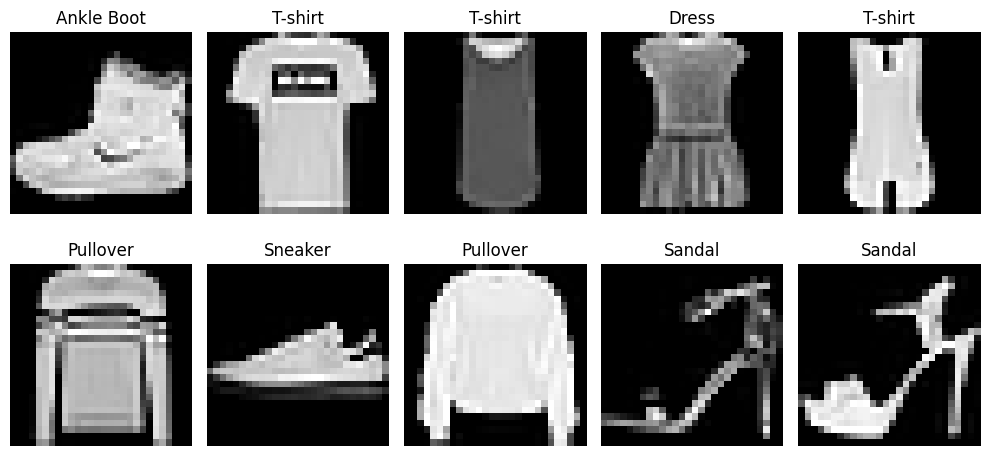

In [8]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
#The pixel values range from 0 to 255. Neural networks train better when values are scaled to 0–1.
X_train = X_train / 255.0
X_test = X_test / 255.0
print(X_train.min())
print(X_train.max())

0.0
0.00392156862745098


In [15]:
#Ann accepts only 1D vector then we will use Flatten layer to convert each image 28x28 into a 784 element vector
model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(256,activation = "relu"),
    Dense(128,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(10,activation = "softmax")
])

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer = "adam",
              loss = "sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )
'''Adam: Efficient optimizer.
Sparse Categorical Crossentropy: Labels are integers (0–9), so one-hot encoding isn't needed.
Accuracy: Measures classification performance.'''

"Adam: Efficient optimizer.\nSparse Categorical Crossentropy: Labels are integers (0–9), so one-hot encoding isn't needed.\nAccuracy: Measures classification performance."

In [21]:
model.fit(X_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.6743 - loss: 0.8675 - val_accuracy: 0.7770 - val_loss: 0.6175
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7909 - loss: 0.5732 - val_accuracy: 0.8067 - val_loss: 0.5329
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8221 - loss: 0.4904 - val_accuracy: 0.8305 - val_loss: 0.4716
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8381 - loss: 0.4474 - val_accuracy: 0.8406 - val_loss: 0.4479
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8478 - loss: 0.4185 - val_accuracy: 0.8408 - val_loss: 0.4501
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8541 - loss: 0.3992 - val_accuracy: 0.8456 - val_loss: 0.4208
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8622 - loss: 0.3773 - val_accuracy: 0.8539 - val_loss: 0.4033
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8669 -

In [26]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8646 - loss: 0.3765
Test Accuracy: 0.8646000027656555
Test Loss: 0.37649616599082947
